**STEP 1.**

Step 1: long-only optimal portfolio with individual cap at 15%
-------------------------------------------------------------
AAPL: 0.0000
AMZN: 0.0000
GOOGL: 0.0101
JPM: 0.1500
META: 0.1500
MSFT: 0.0899
NFLX: 0.1500
NVDA: 0.1500
PG: 0.1500
XOM: 0.1500

Daily expected return: 0.001818
Daily volatility:       0.012560
Daily Sharpe ratio:     0.1448

Annualized expected return: 0.4582
Annualized volatility:       0.1994
Annualized Sharpe ratio:     2.2981


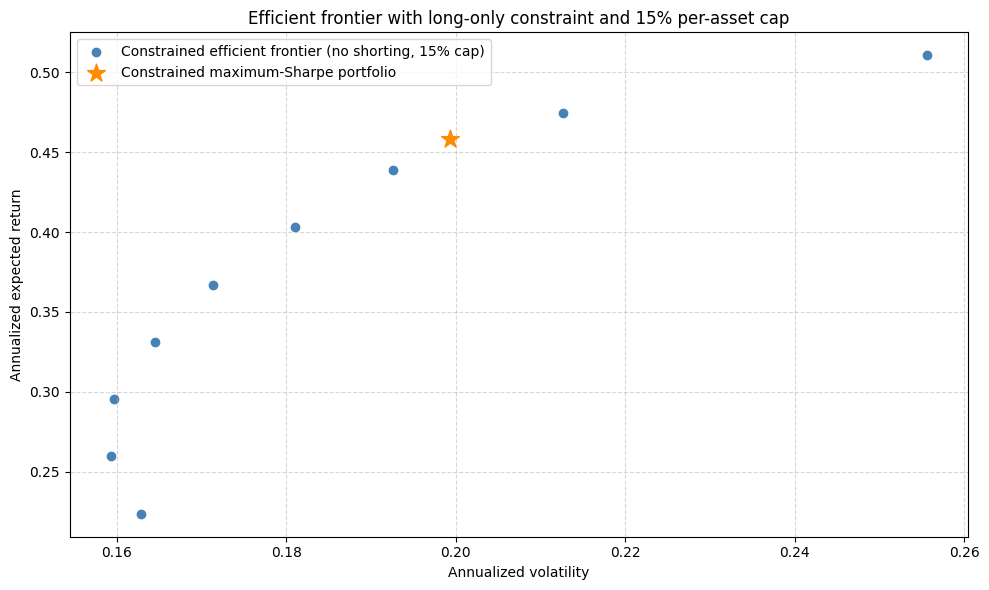

In [ ]:
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance"])
    import yfinance as yf

universe_tickers = ["AAPL", "MSFT", "META", "AMZN", "GOOGL",
                    "NFLX", "NVDA", "JPM", "XOM", "PG"]

training_window_start = "2024-01-01"
training_window_end = "2025-06-30"

raw_price_block = yf.download(
    universe_tickers,
    start=training_window_start,
    end=training_window_end,
    auto_adjust=True,
    progress=False,
)

if isinstance(raw_price_block.columns, pd.MultiIndex):
    adjusted_close_panel = raw_price_block.xs("Close", axis=1, level=0)
else:
    adjusted_close_panel = raw_price_block[["Close"]].copy()
    adjusted_close_panel.columns = universe_tickers

adjusted_close_panel = adjusted_close_panel.dropna(how="all")

daily_return_frame = adjusted_close_panel.pct_change().dropna(how="any")

mean_return_vector = daily_return_frame.mean().values
covariance_canvas = daily_return_frame.cov().values

asset_count = len(mean_return_vector)
starting_blueprint = np.repeat(1.0 / asset_count, asset_count)
weight_limits = tuple((0.0, 0.15) for _ in range(asset_count))

def portfolio_profile(weight_array, mean_vector, covariance_matrix):
    expected_line = float(np.dot(weight_array, mean_vector))
    variance_scalar = float(np.dot(weight_array.T, np.dot(covariance_matrix, weight_array)))
    volatility_scalar = float(np.sqrt(variance_scalar))
    return expected_line, volatility_scalar

def negative_sharpe_score(weight_array, mean_vector, covariance_matrix, riskfree_scalar):
    expected_line, volatility_scalar = portfolio_profile(
        weight_array, mean_vector, covariance_matrix
    )
    if volatility_scalar == 0.0:
        return 1e6
    excess_line = expected_line - riskfree_scalar
    sharpe_measure = excess_line / volatility_scalar
    return -sharpe_measure

riskfree_daily_scalar = 0.0

full_investment_rule = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1.0,
}

sharpe_solution_package = minimize(
    negative_sharpe_score,
    starting_blueprint,
    args=(mean_return_vector, covariance_canvas, riskfree_daily_scalar),
    method="SLSQP",
    bounds=weight_limits,
    constraints=[full_investment_rule],
)

if not sharpe_solution_package.success:
    raise RuntimeError("Maximum Sharpe optimization did not converge; message: "
                       + str(sharpe_solution_package.message))

optimal_weight_array = sharpe_solution_package.x
optimal_expected_line, optimal_volatility_scalar = portfolio_profile(
    optimal_weight_array, mean_return_vector, covariance_canvas
)
optimal_sharpe_scalar = (optimal_expected_line - riskfree_daily_scalar) / optimal_volatility_scalar

ticker_order = daily_return_frame.columns.tolist()
print("Step 1: long-only optimal portfolio with individual cap at 15%")
print("-------------------------------------------------------------")
for one_ticker, one_weight in zip(ticker_order, optimal_weight_array):
    print(f"{one_ticker}: {one_weight:.4f}")

print("\nDaily expected return: {:.6f}".format(optimal_expected_line))
print("Daily volatility:       {:.6f}".format(optimal_volatility_scalar))
print("Daily Sharpe ratio:     {:.4f}".format(optimal_sharpe_scalar))

annualization_scale = 252
annualized_expected_line = optimal_expected_line * annualization_scale
annualized_volatility_scalar = optimal_volatility_scalar * np.sqrt(annualization_scale)
annualized_sharpe_scalar = annualized_expected_line / annualized_volatility_scalar

print("\nAnnualized expected return: {:.4f}".format(annualized_expected_line))
print("Annualized volatility:       {:.4f}".format(annualized_volatility_scalar))
print("Annualized Sharpe ratio:     {:.4f}".format(annualized_sharpe_scalar))

target_return_grid = np.linspace(
    mean_return_vector.min() * 0.5,
    mean_return_vector.max() * 1.5,
    40,
)

frontier_return_list = []
frontier_volatility_list = []

for target_level in target_return_grid:
    def target_return_constraint(weight_array, target=target_level):
        return np.dot(weight_array, mean_return_vector) - target

    frontier_rules = [
        full_investment_rule,
        {"type": "eq", "fun": target_return_constraint},
    ]

    frontier_solution_package = minimize(
        lambda w: portfolio_profile(w, mean_return_vector, covariance_canvas)[1],
        starting_blueprint,
        method="SLSQP",
        bounds=weight_limits,
        constraints=frontier_rules,
    )

    if frontier_solution_package.success:
        resulting_line, resulting_volatility = portfolio_profile(
            frontier_solution_package.x, mean_return_vector, covariance_canvas
        )
        frontier_return_list.append(resulting_line)
        frontier_volatility_list.append(resulting_volatility)

frontier_return_array = np.array(frontier_return_list)
frontier_volatility_array = np.array(frontier_volatility_list)

annualized_frontier_returns = frontier_return_array * annualization_scale
annualized_frontier_volatilities = frontier_volatility_array * np.sqrt(annualization_scale)

plt.figure(figsize=(10, 6))
plt.scatter(
    annualized_frontier_volatilities,
    annualized_frontier_returns,
    c="steelblue",
    label="Constrained efficient frontier (no shorting, 15% cap)",
)
plt.scatter(
    annualized_volatility_scalar,
    annualized_expected_line,
    c="darkorange",
    marker="*",
    s=180,
    label="Constrained maximum-Sharpe portfolio",
)
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.title("Efficient frontier with long-only constraint and 15% per-asset cap")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**STEP 2.**

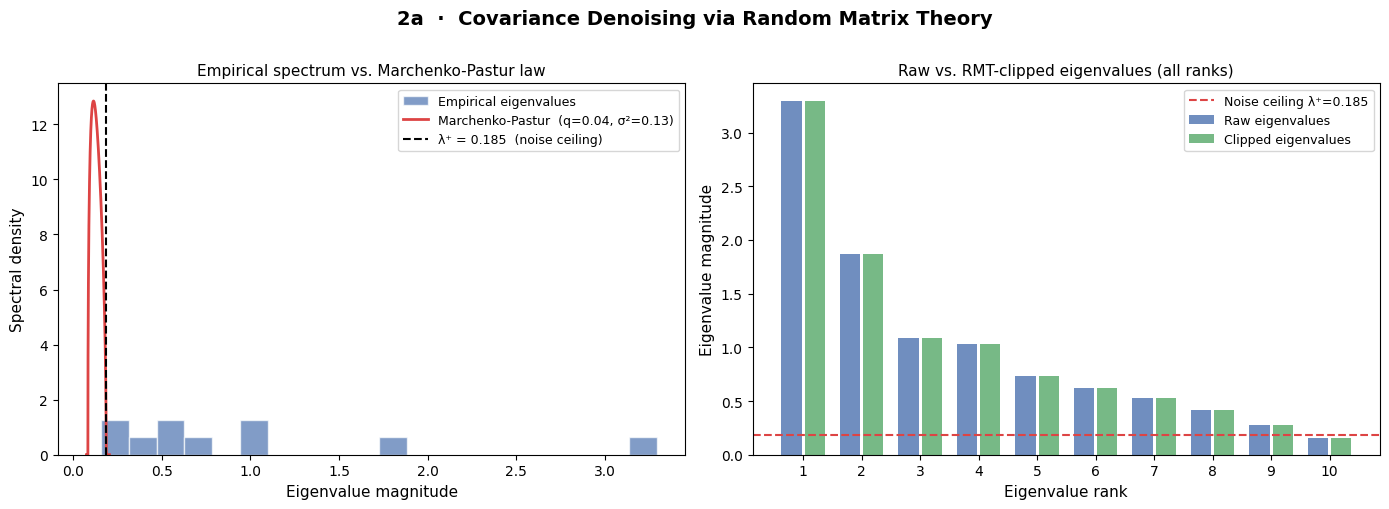

[2a] λ⁺ noise ceiling: 0.1854 | Noisy eigenvalues clipped: 1 / 10


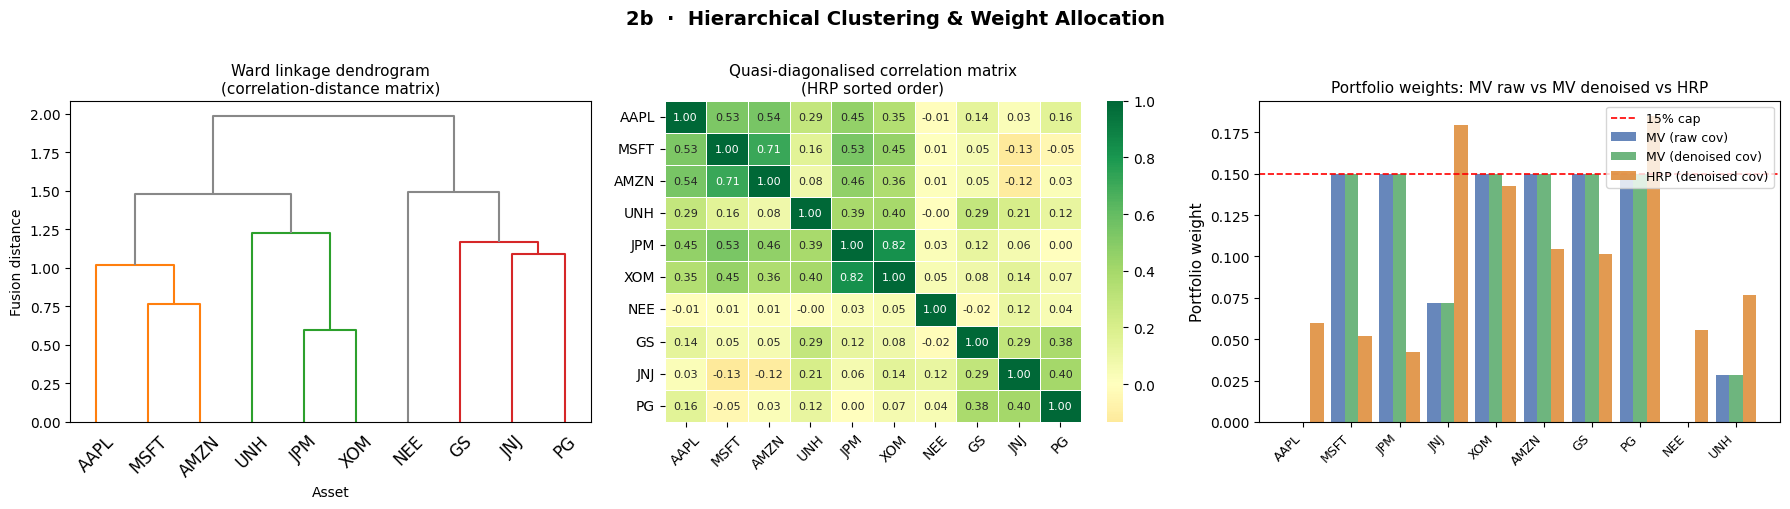


[2b] HRP weights:
Ticker
AAPL    0.0597
AMZN    0.0520
GS      0.0424
JNJ     0.1797
JPM     0.1427
MSFT    0.1045
NEE     0.1017
PG      0.1849
UNH     0.0555
XOM     0.0768

[2c] Running walk-forward backtests (3 strategies)…

[2c] Walk-forward performance metrics:

                Annualised Return  Annualised Vol  Sharpe Ratio  Sortino Ratio  Max Drawdown  Expected Shortfall
MV (raw cov)               0.0579          0.1467        0.3945         0.4944       -0.1671           -0.022038
MV (denoised)              0.0579          0.1467        0.3945         0.4944       -0.1671           -0.022038
HRP (denoised)             0.0148          0.1342        0.1102         0.1385       -0.1382           -0.019752


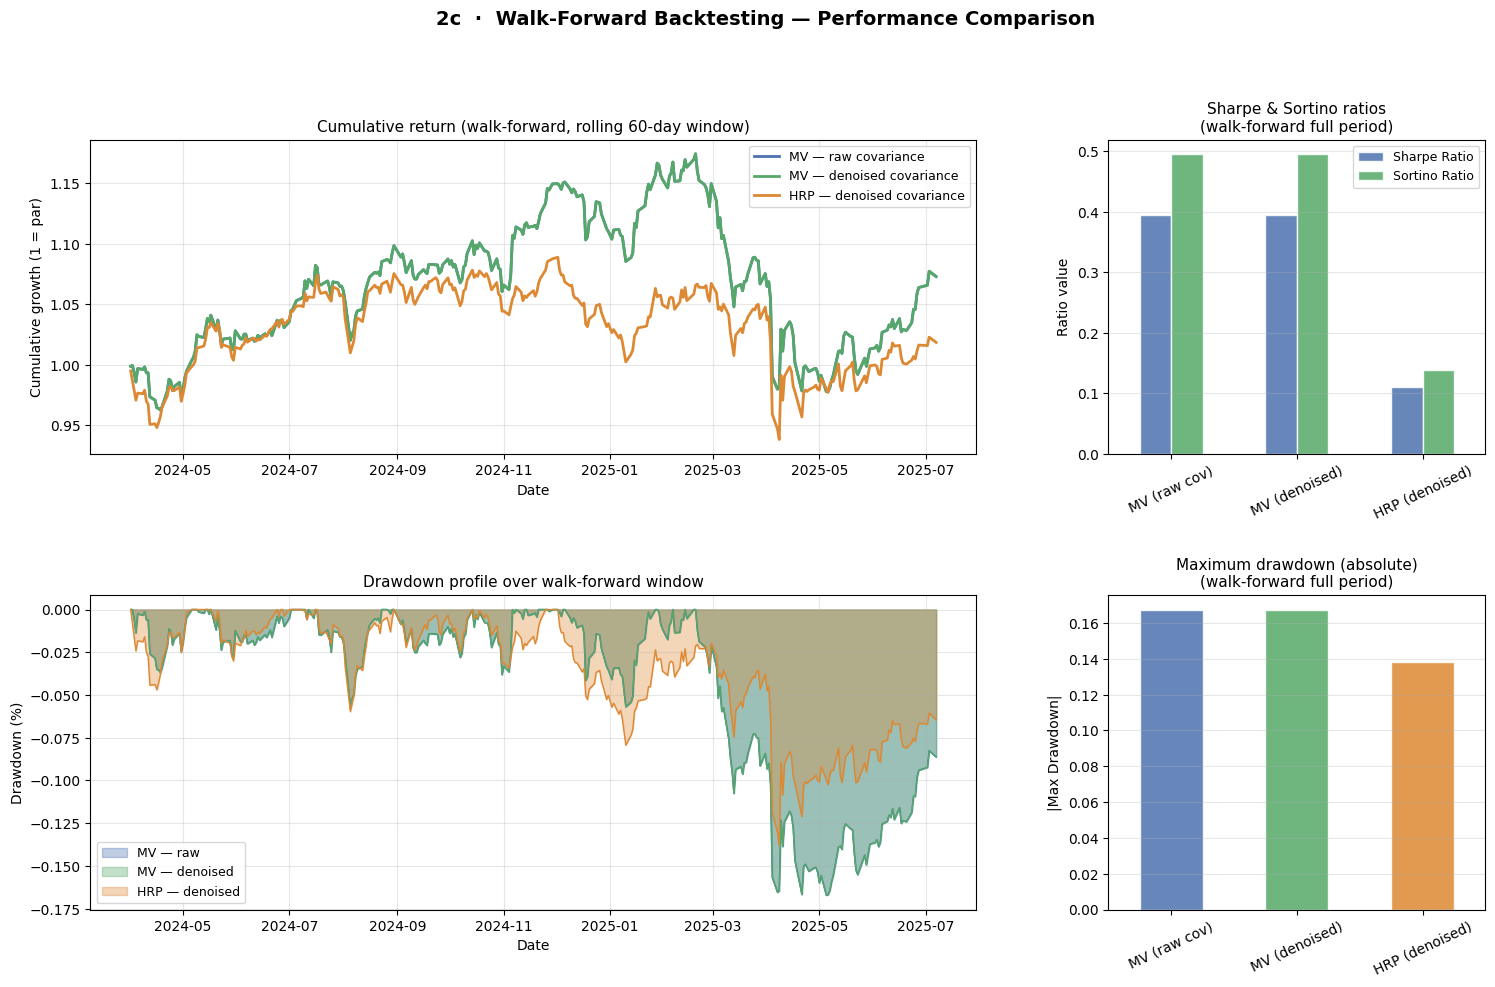

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings("ignore")

equity_basket = ["AAPL", "MSFT", "JPM", "JNJ", "XOM",
                 "AMZN", "GS", "PG", "NEE", "UNH"]

training_start  = "2024-01-01"
training_end    = "2025-06-30"
holdout_start   = "2025-07-01"
holdout_end     = "2025-07-31"

raw_prices_train = yf.download(equity_basket,
                                start=training_start,
                                end=training_end,
                                auto_adjust=True,
                                progress=False)["Close"].dropna()

raw_prices_hold  = yf.download(equity_basket,
                                start=holdout_start,
                                end=holdout_end,
                                auto_adjust=True,
                                progress=False)["Close"].dropna()

log_rets_train = np.log(raw_prices_train / raw_prices_train.shift(1)).dropna()
log_rets_hold  = np.log(raw_prices_hold  / raw_prices_hold.shift(1)).dropna()

n_assets = len(equity_basket)
n_obs    = len(log_rets_train)


def fit_marchenko_pastur(eigenvalues, ratio_q, sigma2=1.0, n_pts=1000):
    lam_plus  = sigma2 * (1 + np.sqrt(ratio_q))**2
    lam_minus = sigma2 * (1 - np.sqrt(ratio_q))**2
    grid = np.linspace(lam_minus * 0.9, lam_plus * 1.1, n_pts)
    with np.errstate(invalid="ignore"):
        density = (np.sqrt(np.maximum((lam_plus - grid) * (grid - lam_minus), 0))
                   / (2 * np.pi * ratio_q * sigma2 * grid))
    return grid, density, lam_plus, lam_minus


def calibrate_q_sigma(eigenvalues, ratio_q_init, n_grid=50):
    best_loss = np.inf
    best_q, best_s2 = ratio_q_init, 1.0
    for q_try in np.linspace(ratio_q_init * 0.5, ratio_q_init * 1.5, n_grid):
        for s2_try in np.linspace(0.1, 1.5, n_grid):
            lam_plus = s2_try * (1 + np.sqrt(q_try))**2
            noise_ev = eigenvalues[eigenvalues <= lam_plus]
            if len(noise_ev) == 0:
                continue
            emp_var = noise_ev.var()
            theory_var = s2_try**2 * (1.0 / q_try - 1.0) if q_try < 1 else s2_try**2
            loss = (emp_var - theory_var)**2
            if loss < best_loss:
                best_loss = loss
                best_q, best_s2 = q_try, s2_try
    return best_q, best_s2


def denoise_cov_rmt(returns_df):
    cov_empirical  = returns_df.cov().values
    corr_empirical = returns_df.corr().values
    std_vec        = returns_df.std().values

    eigenvalues_raw, eigenvectors = np.linalg.eigh(corr_empirical)
    eigenvalues_raw = np.sort(eigenvalues_raw)[::-1]
    eigenvectors    = eigenvectors[:, ::-1]

    raw_q = n_assets / n_obs
    fitted_q, fitted_sigma2 = calibrate_q_sigma(eigenvalues_raw, raw_q)

    lam_plus = fitted_sigma2 * (1 + np.sqrt(fitted_q))**2

    noise_mask      = eigenvalues_raw <= lam_plus
    noise_mean      = eigenvalues_raw[noise_mask].mean()
    clipped_eigs    = eigenvalues_raw.copy()
    clipped_eigs[noise_mask] = noise_mean

    corr_denoised = eigenvectors @ np.diag(clipped_eigs) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1.0)

    outer_std = np.outer(std_vec, std_vec)
    cov_denoised = corr_denoised * outer_std

    return cov_denoised, corr_denoised, corr_empirical, eigenvalues_raw, clipped_eigs, lam_plus, fitted_q, fitted_sigma2


cov_denoised, corr_denoised, corr_empirical, ev_raw, ev_clipped, lam_plus, fitted_q, fitted_s2 = \
    denoise_cov_rmt(log_rets_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("2a  ·  Covariance Denoising via Random Matrix Theory",
             fontsize=14, fontweight="bold", y=1.01)

mp_grid, mp_density, _, _ = fit_marchenko_pastur(ev_raw, fitted_q, fitted_s2)

ax0 = axes[0]
ax0.hist(ev_raw, bins=20, density=True, color="#4C72B0", alpha=0.7,
         edgecolor="white", label="Empirical eigenvalues")
ax0.plot(mp_grid, mp_density, color="#DD4444", lw=2,
         label=f"Marchenko-Pastur  (q={fitted_q:.2f}, σ²={fitted_s2:.2f})")
ax0.axvline(lam_plus, color="black", ls="--", lw=1.5,
            label=f"λ⁺ = {lam_plus:.3f}  (noise ceiling)")
ax0.set_xlabel("Eigenvalue magnitude", fontsize=11)
ax0.set_ylabel("Spectral density", fontsize=11)
ax0.set_title("Empirical spectrum vs. Marchenko-Pastur law", fontsize=11)
ax0.legend(fontsize=9)

ax1 = axes[1]
x_idx = np.arange(1, n_assets + 1)
ax1.bar(x_idx - 0.2, ev_raw,     width=0.35, color="#4C72B0", alpha=0.8, label="Raw eigenvalues")
ax1.bar(x_idx + 0.2, ev_clipped, width=0.35, color="#55A868", alpha=0.8, label="Clipped eigenvalues")
ax1.axhline(lam_plus, color="#DD4444", ls="--", lw=1.5, label=f"Noise ceiling λ⁺={lam_plus:.3f}")
ax1.set_xlabel("Eigenvalue rank", fontsize=11)
ax1.set_ylabel("Eigenvalue magnitude", fontsize=11)
ax1.set_title("Raw vs. RMT-clipped eigenvalues (all ranks)", fontsize=11)
ax1.legend(fontsize=9)
ax1.set_xticks(x_idx)

plt.tight_layout()
plt.show()
print(f"[2a] λ⁺ noise ceiling: {lam_plus:.4f} | "
      f"Noisy eigenvalues clipped: {(ev_raw <= lam_plus).sum()} / {n_assets}")

def corr_to_distance(corr_matrix):
    dist_matrix = np.sqrt(np.clip(2 * (1 - corr_matrix), 0, None))
    np.fill_diagonal(dist_matrix, 0.0)
    return dist_matrix


def build_hrp_weights(returns_df, cov_matrix):
    corr_mat  = returns_df.corr().values
    dist_mat  = corr_to_distance(corr_mat)
    condensed = squareform(dist_mat)

    linkage_matrix = linkage(condensed, method="ward")

    sorted_order = []
    def _recursive_sort(node, n_leaves, link_mat):
        if node < n_leaves:
            sorted_order.append(node)
        else:
            idx = int(node - n_leaves)
            _recursive_sort(int(link_mat[idx, 0]), n_leaves, link_mat)
            _recursive_sort(int(link_mat[idx, 1]), n_leaves, link_mat)

    _recursive_sort(2 * n_assets - 2, n_assets, linkage_matrix)

    weights_hrp = pd.Series(1.0, index=range(n_assets))

    def _bisect(items):
        if len(items) <= 1:
            return
        mid = len(items) // 2
        left_cluster  = items[:mid]
        right_cluster = items[mid:]
        cov_left  = cov_matrix[np.ix_(left_cluster,  left_cluster)]
        cov_right = cov_matrix[np.ix_(right_cluster, right_cluster)]
        w_left    = np.ones(len(left_cluster))  / len(left_cluster)
        w_right   = np.ones(len(right_cluster)) / len(right_cluster)
        var_left  = w_left  @ cov_left  @ w_left
        var_right = w_right @ cov_right @ w_right
        alpha = 1 - var_left / (var_left + var_right)
        weights_hrp[left_cluster]  *= alpha
        weights_hrp[right_cluster] *= (1 - alpha)
        _bisect(left_cluster)
        _bisect(right_cluster)

    _bisect(sorted_order)

    weights_series = pd.Series(weights_hrp.values / weights_hrp.sum(),
                                index=returns_df.columns)
    return weights_series, linkage_matrix, sorted_order, dist_mat


hrp_weights, link_mat, sorted_order, dist_mat_hrp = \
    build_hrp_weights(log_rets_train, cov_denoised)

mean_rets = log_rets_train.mean().values
cov_raw   = log_rets_train.cov().values

def mv_optimize(cov, mean_r, max_w=0.15):
    n = len(mean_r)
    def neg_sharpe(w):
        port_ret = w @ mean_r
        port_vol = np.sqrt(w @ cov @ w)
        return -port_ret / (port_vol + 1e-10)
    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds      = [(0, max_w)] * n
    w0 = np.ones(n) / n
    res = minimize(neg_sharpe, w0, method="SLSQP",
                   bounds=bounds, constraints=constraints,
                   options={"ftol": 1e-9, "maxiter": 1000})
    return res.x

mv_weights_raw      = mv_optimize(cov_raw,      mean_rets)
mv_weights_denoised = mv_optimize(cov_denoised, mean_rets)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("2b  ·  Hierarchical Clustering & Weight Allocation",
             fontsize=14, fontweight="bold", y=1.01)

ax0 = axes[0]
dendrogram(link_mat, labels=equity_basket, orientation="top", ax=ax0,
           color_threshold=0.7 * max(link_mat[:, 2]),
           above_threshold_color="#888888")
ax0.set_title("Ward linkage dendrogram\n(correlation-distance matrix)", fontsize=11)
ax0.set_xlabel("Asset", fontsize=10)
ax0.set_ylabel("Fusion distance", fontsize=10)
ax0.tick_params(axis="x", rotation=45)

ax1 = axes[1]
quasi_diag_corr = log_rets_train.corr().values[np.ix_(sorted_order, sorted_order)]
sorted_labels   = [equity_basket[i] for i in sorted_order]
sns.heatmap(quasi_diag_corr, ax=ax1,
            xticklabels=sorted_labels, yticklabels=sorted_labels,
            cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            linewidths=0.4, linecolor="white", annot_kws={"size": 8})
ax1.set_title("Quasi-diagonalised correlation matrix\n(HRP sorted order)", fontsize=11)
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(axis="y", rotation=0)

ax2 = axes[2]
width = 0.28
x_pos = np.arange(n_assets)
ax2.bar(x_pos - width, mv_weights_raw,      width=width, color="#4C72B0",
        alpha=0.85, label="MV (raw cov)")
ax2.bar(x_pos,         mv_weights_denoised, width=width, color="#55A868",
        alpha=0.85, label="MV (denoised cov)")
ax2.bar(x_pos + width, hrp_weights.values,  width=width, color="#DD8833",
        alpha=0.85, label="HRP (denoised cov)")
ax2.axhline(0.15, color="red", ls="--", lw=1.2, label="15% cap")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(equity_basket, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Portfolio weight", fontsize=11)
ax2.set_title("Portfolio weights: MV raw vs MV denoised vs HRP", fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("\n[2b] HRP weights:")
print(hrp_weights.round(4).to_string())


def portfolio_metrics(ret_series, rf_daily=0.0):
    total_ret    = (1 + ret_series).prod() - 1
    ann_ret      = (1 + total_ret) ** (252 / len(ret_series)) - 1
    ann_vol      = ret_series.std() * np.sqrt(252)
    sharpe       = (ann_ret - rf_daily * 252) / (ann_vol + 1e-10)
    neg_rets     = ret_series[ret_series < 0]
    sortino_denom = neg_rets.std() * np.sqrt(252) if len(neg_rets) > 1 else 1e-10
    sortino      = (ann_ret - rf_daily * 252) / sortino_denom
    cm           = (1 + ret_series).cumprod()
    roll_max      = cm.cummax()
    drawdown      = (cm - roll_max) / roll_max
    max_dd        = drawdown.min()
    var_5         = ret_series.quantile(0.05)
    es_5          = ret_series[ret_series <= var_5].mean()
    return {
        "Annualised Return":  round(ann_ret, 4),
        "Annualised Vol":     round(ann_vol, 4),
        "Sharpe Ratio":       round(sharpe, 4),
        "Sortino Ratio":      round(sortino, 4),
        "Max Drawdown":       round(max_dd, 4),
        "Expected Shortfall": round(es_5, 6),
    }


def walk_forward_backtest(full_returns, method="mv_raw",
                          train_days=60, step_days=21):
    portfolio_daily_rets = []
    portfolio_dates      = []
    n_total = len(full_returns)
    start   = 0

    while start + train_days + step_days <= n_total:
        window_rets = full_returns.iloc[start: start + train_days]
        test_rets   = full_returns.iloc[start + train_days: start + train_days + step_days]

        cov_w   = window_rets.cov().values
        mean_w  = window_rets.mean().values

        if method == "mv_raw":
            wts = mv_optimize(cov_w, mean_w)
            wts = pd.Series(wts, index=full_returns.columns)

        elif method == "mv_denoised":
            cov_dn, *_ = denoise_cov_rmt(window_rets)
            wts = mv_optimize(cov_dn, mean_w)
            wts = pd.Series(wts, index=full_returns.columns)

        elif method == "hrp_denoised":
            cov_dn, *_ = denoise_cov_rmt(window_rets)
            wts, _, _, _ = build_hrp_weights(window_rets, cov_dn)

        port_rets = test_rets @ wts
        portfolio_daily_rets.extend(port_rets.tolist())
        portfolio_dates.extend(test_rets.index.tolist())
        start += step_days

    return pd.Series(portfolio_daily_rets, index=portfolio_dates, name=method)


all_rets = pd.concat([log_rets_train, log_rets_hold])

print("\n[2c] Running walk-forward backtests (3 strategies)…")
ret_mv_raw      = walk_forward_backtest(all_rets, method="mv_raw")
ret_mv_denoised = walk_forward_backtest(all_rets, method="mv_denoised")
ret_hrp_denoised= walk_forward_backtest(all_rets, method="hrp_denoised")

common_idx = ret_mv_raw.index.intersection(ret_mv_denoised.index).intersection(ret_hrp_denoised.index)
ret_mv_raw       = ret_mv_raw.loc[common_idx]
ret_mv_denoised  = ret_mv_denoised.loc[common_idx]
ret_hrp_denoised = ret_hrp_denoised.loc[common_idx]

cm_mv_raw       = (1 + ret_mv_raw).cumprod()
cm_mv_denoised  = (1 + ret_mv_denoised).cumprod()
cm_hrp_denoised = (1 + ret_hrp_denoised).cumprod()

metrics_table = pd.DataFrame({
    "MV (raw cov)":      portfolio_metrics(ret_mv_raw),
    "MV (denoised)":     portfolio_metrics(ret_mv_denoised),
    "HRP (denoised)":    portfolio_metrics(ret_hrp_denoised),
}).T

print("\n[2c] Walk-forward performance metrics:\n")
print(metrics_table.to_string())

fig = plt.figure(figsize=(18, 10))
fig.suptitle("2c  ·  Walk-Forward Backtesting — Performance Comparison",
             fontsize=14, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

palette = {"MV (raw cov)": "#4C72B0",
           "MV (denoised)": "#55A868",
           "HRP (denoised)": "#DD8833"}

ax_cm = fig.add_subplot(gs[0, :2])
ax_cm.plot(cm_mv_raw.index,       cm_mv_raw.values,       color=palette["MV (raw cov)"],
            lw=2, label="MV — raw covariance")
ax_cm.plot(cm_mv_denoised.index,  cm_mv_denoised.values,  color=palette["MV (denoised)"],
            lw=2, label="MV — denoised covariance")
ax_cm.plot(cm_hrp_denoised.index, cm_hrp_denoised.values, color=palette["HRP (denoised)"],
            lw=2, label="HRP — denoised covariance")
ax_cm.set_title("Cumulative return (walk-forward, rolling 60-day window)", fontsize=11)
ax_cm.set_ylabel("Cumulative growth (1 = par)", fontsize=10)
ax_cm.set_xlabel("Date", fontsize=10)
ax_cm.legend(fontsize=9)
ax_cm.grid(alpha=0.3)

ax_dd = fig.add_subplot(gs[1, :2])
for ret_s, label, col in [
    (ret_mv_raw,      "MV — raw",      palette["MV (raw cov)"]),
    (ret_mv_denoised, "MV — denoised", palette["MV (denoised)"]),
    (ret_hrp_denoised,"HRP — denoised",palette["HRP (denoised)"])]:
    cm_s = (1 + ret_s).cumprod()
    dd_s  = (cm_s - cm_s.cummax()) / cm_s.cummax()
    ax_dd.fill_between(dd_s.index, dd_s.values, 0,
                       alpha=0.35, color=col, label=label)
    ax_dd.plot(dd_s.index, dd_s.values, color=col, lw=1)
ax_dd.set_title("Drawdown profile over walk-forward window", fontsize=11)
ax_dd.set_ylabel("Drawdown (%)", fontsize=10)
ax_dd.set_xlabel("Date", fontsize=10)
ax_dd.legend(fontsize=9)
ax_dd.grid(alpha=0.3)

ax_met = fig.add_subplot(gs[0, 2])
metric_cols = ["Sharpe Ratio", "Sortino Ratio"]
bar_data    = metrics_table[metric_cols]
bar_data.plot(kind="bar", ax=ax_met,
              color=["#4C72B0", "#55A868"],
              alpha=0.85, edgecolor="white")
ax_met.set_title("Sharpe & Sortino ratios\n(walk-forward full period)", fontsize=11)
ax_met.set_ylabel("Ratio value", fontsize=10)
ax_met.tick_params(axis="x", rotation=25)
ax_met.legend(fontsize=9)
ax_met.grid(axis="y", alpha=0.3)

ax_dd2 = fig.add_subplot(gs[1, 2])
dd_vals = metrics_table["Max Drawdown"].abs()
dd_vals.plot(kind="bar", ax=ax_dd2,
             color=["#4C72B0", "#55A868", "#DD8833"],
             alpha=0.85, edgecolor="white")
ax_dd2.set_title("Maximum drawdown (absolute)\n(walk-forward full period)", fontsize=11)
ax_dd2.set_ylabel("|Max Drawdown|", fontsize=10)
ax_dd2.tick_params(axis="x", rotation=25)
ax_dd2.grid(axis="y", alpha=0.3)
plt.show()

**STEP 3.**

LW shrinkage: 0.0000

Ticker    RawTan    ShrTan    RawHRP    ShrHRP
  AAPL    0.0000    0.0000    0.0561    0.0561
  AMZN    0.0000    0.0000    0.0493    0.0493
 GOOGL    0.0101    0.0101    0.0559    0.0559
   JPM    0.1500    0.1500    0.0626    0.0626
  META    0.1500    0.1500    0.0270    0.0270
  MSFT    0.0899    0.0899    0.1289    0.1289
  NFLX    0.1500    0.1500    0.0696    0.0696
  NVDA    0.1500    0.1500    0.0345    0.0345
    PG    0.1500    0.1500    0.3207    0.3207
   XOM    0.1500    0.1500    0.1954    0.1954

--- Annual Metrics ---
Raw Tangency: Return=0.4582  Vol=0.1994  Sharpe=2.2981
Shrunk Tangency: Return=0.4582  Vol=0.1994  Sharpe=2.2981
Raw HRP: Return=0.2399  Vol=0.1396  Sharpe=1.7186
Shrunk HRP: Return=0.2399  Vol=0.1396  Sharpe=1.7186


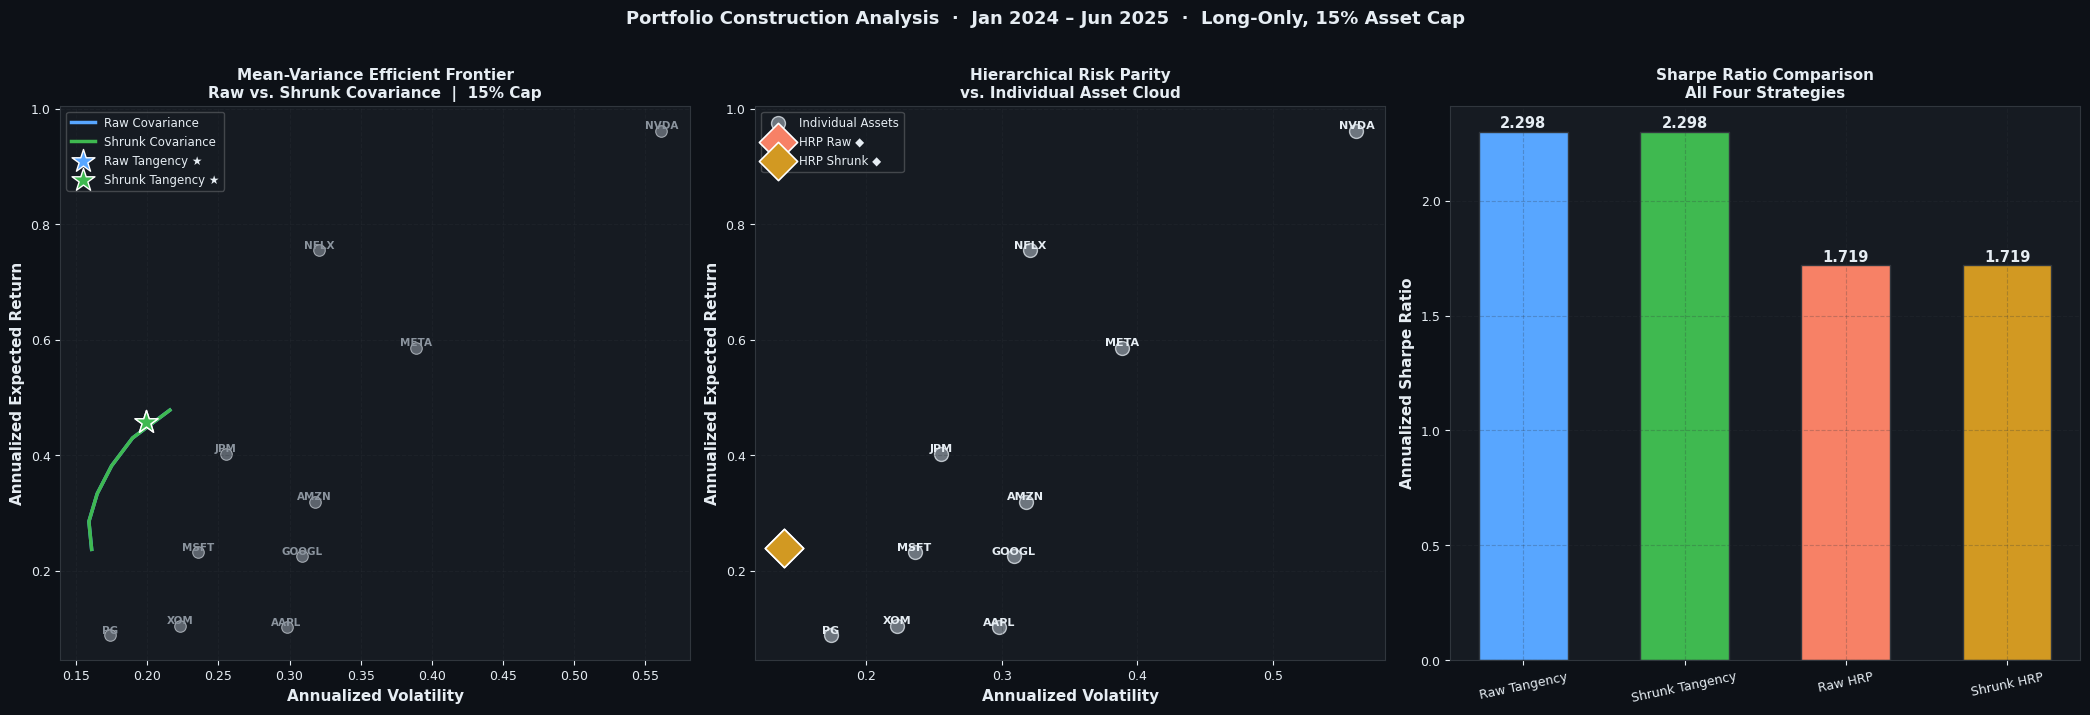

Done.


In [ ]:
import sys
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

warnings.filterwarnings('ignore')

try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance"])
    import yfinance as yf


universe_tickers = ["AAPL", "MSFT", "META", "AMZN", "GOOGL",
                    "NFLX", "NVDA", "JPM", "XOM", "PG"]

raw_price_block = yf.download(
    universe_tickers,
    start="2024-01-01",
    end="2025-06-30",
    auto_adjust=True,
    progress=False,
)

if isinstance(raw_price_block.columns, pd.MultiIndex):
    close_panel = raw_price_block.xs("Close", axis=1, level=0)
else:
    close_panel = raw_price_block["Close"].copy()
    close_panel.columns = universe_tickers

close_panel = close_panel.dropna(how="all")
daily_rets  = close_panel.pct_change().dropna(how="any")

mu_vec     = daily_rets.mean().values
sigma_raw  = daily_rets.cov().values
n          = len(mu_vec)
tickers    = list(daily_rets.columns)


def ledoit_wolf_blend(S):
    T, p    = daily_rets.shape
    X       = daily_rets.values - daily_rets.values.mean(axis=0)
    diags   = np.diag(S)
    off_mask = ~np.eye(p, dtype=bool)
    rho_avg = np.mean(S[off_mask])
    prior   = rho_avg * np.outer(np.sqrt(diags), np.sqrt(diags))
    np.fill_diagonal(prior, diags)
    V       = (X.T @ X / T) ** 2
    phi     = np.sum(V - S ** 2)
    dv      = np.diag(X.T @ X / T)
    mu_val  = np.trace(V) - np.sum(dv ** 2)
    cs      = np.sum(S - np.outer(np.diag(prior), np.diag(prior)))
    rho_v   = phi - mu_val - cs
    dist    = np.sum((S - prior) ** 2)
    alpha   = min(1.0, max(0.0, (rho_v / dist) / T)) if dist != 0 else 0.0
    return alpha * prior + (1 - alpha) * S, alpha


sigma_shrunk, alpha_lw = ledoit_wolf_blend(sigma_raw)
print(f"LW shrinkage: {alpha_lw:.4f}")

w0     = np.full(n, 1.0 / n)
bounds = [(0.0, 0.15)] * n
eq_con = {"type": "eq", "fun": lambda w: w.sum() - 1.0}


def port_stats(w, mu, S):
    ret = float(w @ mu)
    vol = float(np.sqrt(max(float(w @ S @ w), 0.0)))
    return ret, vol


def neg_sharpe(w, mu, S):
    r, v = port_stats(w, mu, S)
    return -(r / v) if v > 0 else 1e6


tan_raw    = minimize(neg_sharpe, w0, args=(mu_vec, sigma_raw),
                      method="SLSQP", bounds=bounds, constraints=[eq_con])
tan_shrunk = minimize(neg_sharpe, w0, args=(mu_vec, sigma_shrunk),
                      method="SLSQP", bounds=bounds, constraints=[eq_con])


def hrp_weights(S):
    corr = np.corrcoef(daily_rets.values.T)
    corr = (corr + corr.T) / 2
    np.fill_diagonal(corr, 1.0)
    dist = np.sqrt(np.clip((1.0 - corr) / 2.0, 0.0, 1.0))
    np.fill_diagonal(dist, 0.0)
    dist = (dist + dist.T) / 2.0
    cond = squareform(dist, checks=False)
    tree = linkage(cond, method='single')
    clusters = fcluster(tree, n, criterion='maxclust')
    order    = list(np.argsort(clusters))

    def ivp_var(idx):
        sub = S[np.ix_(idx, idx)]
        iv  = 1.0 / np.maximum(np.diag(sub), 1e-12)
        return float(iv @ sub @ iv) / max(iv.sum() ** 2, 1e-20)

    def bisect(items):
        if len(items) == 1:
            return {items[0]: 1.0}
        m       = len(items) // 2
        L, R    = items[:m], items[m:]
        vL, vR  = ivp_var(L), ivp_var(R)
        a       = 1.0 - vL / (vL + vR)
        merged  = {k: v * a       for k, v in bisect(L).items()}
        merged |= {k: v * (1 - a) for k, v in bisect(R).items()}
        return merged

    alloc = bisect(order)
    w     = np.array([alloc[i] for i in range(n)])
    return w / w.sum(), tree, order


hrp_raw_w,    tree_raw,    ord_raw    = hrp_weights(sigma_raw)
hrp_shrunk_w, tree_shrunk, ord_shrunk = hrp_weights(sigma_shrunk)

Y = 252
portfolios = [
    ("Raw Tangency",    tan_raw.x,    sigma_raw),
    ("Shrunk Tangency", tan_shrunk.x, sigma_shrunk),
    ("Raw HRP",         hrp_raw_w,    sigma_raw),
    ("Shrunk HRP",      hrp_shrunk_w, sigma_shrunk),
]

print(f"\n{'Ticker':>6}  {'RawTan':>8}  {'ShrTan':>8}  {'RawHRP':>8}  {'ShrHRP':>8}")
for t, w1, w2, w3, w4 in zip(tickers,
                               tan_raw.x, tan_shrunk.x,
                               hrp_raw_w, hrp_shrunk_w):
    print(f"{t:>6}  {w1:>8.4f}  {w2:>8.4f}  {w3:>8.4f}  {w4:>8.4f}")

metric_rows = []
print("\n--- Annual Metrics ---")
for name, w, S in portfolios:
    r, v   = port_stats(w, mu_vec, S)
    ar, av = r * Y, v * np.sqrt(Y)
    sr     = ar / av if av > 0 else 0.0
    metric_rows.append({"Portfolio": name, "Return": ar, "Vol": av, "Sharpe": sr})
    print(f"{name}: Return={ar:.4f}  Vol={av:.4f}  Sharpe={sr:.4f}")


# ─── Efficient frontier helper ────────────────────────────────────────────────
def build_frontier(S_mat, n_pts=30):
    target_rets = np.linspace(mu_vec.min() * 0.5, mu_vec.max() * 1.5, n_pts)
    fv, fy = [], []
    for tgt in target_rets:
        cons = [eq_con,
                {"type": "eq", "fun": lambda w, y=tgt: w @ mu_vec - y}]
        res  = minimize(lambda w: port_stats(w, mu_vec, S_mat)[1],
                        w0, method="SLSQP", bounds=bounds, constraints=cons)
        if res.success:
            r, v = port_stats(res.x, mu_vec, S_mat)
            fy.append(r * Y); fv.append(v * np.sqrt(Y))
    return np.array(fv), np.array(fy)


fv_raw,    fy_raw    = build_frontier(sigma_raw)
fv_shrunk, fy_shrunk = build_frontier(sigma_shrunk)


# ─── Plotting ─────────────────────────────────────────────────────────────────
BG   = '#0d1117'
CARD = '#161b22'
GRID = '#30363d'
T1   = '#e6edf3'
T2   = '#8b949e'
C1   = '#58a6ff'
C2   = '#3fb950'
C3   = '#f78166'
C4   = '#d29922'

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors=T1, labelsize=9)
    ax.xaxis.label.set_color(T1)
    ax.yaxis.label.set_color(T1)
    ax.title.set_color(T1)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID)
    ax.grid(True, alpha=0.25, linestyle='--', color=GRID)

# Panel 1 – Efficient frontiers
ax1 = axes[0]
ax1.plot(fv_raw,    fy_raw,    color=C1, lw=2.5, label='Raw Covariance')
ax1.plot(fv_shrunk, fy_shrunk, color=C2, lw=2.5, label='Shrunk Covariance')

r_rt, v_rt = port_stats(tan_raw.x,    mu_vec, sigma_raw)
r_st, v_st = port_stats(tan_shrunk.x, mu_vec, sigma_shrunk)
ax1.scatter([v_rt * np.sqrt(Y)], [r_rt * Y], c=C1, s=300,
            marker='*', edgecolors='white', lw=1, zorder=9, label='Raw Tangency ★')
ax1.scatter([v_st * np.sqrt(Y)], [r_st * Y], c=C2, s=300,
            marker='*', edgecolors='white', lw=1, zorder=9, label='Shrunk Tangency ★')

ind_v = np.sqrt(np.diag(sigma_raw)) * np.sqrt(Y)
ind_r = mu_vec * Y
ax1.scatter(ind_v, ind_r, c=T2, s=70, alpha=0.6, edgecolors=T1, lw=0.8)
for t, r, v in zip(tickers, ind_r, ind_v):
    ax1.annotate(t, (v, r), color=T2, fontsize=7.5,
                 ha='center', va='bottom', fontweight='bold')

ax1.set_xlabel('Annualized Volatility',      fontsize=11, fontweight='bold')
ax1.set_ylabel('Annualized Expected Return', fontsize=11, fontweight='bold')
ax1.set_title('Mean-Variance Efficient Frontier\nRaw vs. Shrunk Covariance  |  15% Cap', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8.5, framealpha=0.25, labelcolor=T1, facecolor=CARD)

# Panel 2 – HRP vs asset cloud
ax2 = axes[1]
ax2.scatter(ind_v, ind_r, c=T2, s=100, alpha=0.75, edgecolors=T1, lw=1.0, label='Individual Assets')
for t, r, v in zip(tickers, ind_r, ind_v):
    ax2.annotate(t, (v, r), color=T1, fontsize=8,
                 ha='center', va='bottom', fontweight='bold')

r_rh, v_rh = port_stats(hrp_raw_w,    mu_vec, sigma_raw)
r_sh, v_sh = port_stats(hrp_shrunk_w, mu_vec, sigma_shrunk)
ax2.scatter([v_rh * np.sqrt(Y)], [r_rh * Y], c=C3, s=380,
            marker='D', edgecolors='white', lw=1.2, zorder=9, label='HRP Raw ◆')
ax2.scatter([v_sh * np.sqrt(Y)], [r_sh * Y], c=C4, s=380,
            marker='D', edgecolors='white', lw=1.2, zorder=9, label='HRP Shrunk ◆')

ax2.set_xlabel('Annualized Volatility',      fontsize=11, fontweight='bold')
ax2.set_ylabel('Annualized Expected Return', fontsize=11, fontweight='bold')
ax2.set_title('Hierarchical Risk Parity\nvs. Individual Asset Cloud', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8.5, framealpha=0.25, labelcolor=T1, facecolor=CARD)

# Panel 3 – Sharpe bars
ax3 = axes[2]
names_bar   = [r["Portfolio"]  for r in metric_rows]
sharpes_bar = [r["Sharpe"]     for r in metric_rows]
bar_colors  = [C1, C2, C3, C4]
bars = ax3.bar(names_bar, sharpes_bar, color=bar_colors,
               edgecolor=GRID, linewidth=1.0, width=0.55)
for bar, val in zip(bars, sharpes_bar):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom',
             color=T1, fontsize=10.5, fontweight='bold')
ax3.set_ylabel('Annualized Sharpe Ratio', fontsize=11, fontweight='bold')
ax3.set_title('Sharpe Ratio Comparison\nAll Four Strategies', fontsize=11, fontweight='bold')
ax3.set_xticklabels(names_bar, fontsize=9, rotation=12)

fig.suptitle(
    'Portfolio Construction Analysis  ·  Jan 2024 – Jun 2025  ·  Long-Only, 15% Asset Cap',
    fontsize=13, fontweight='bold', color=T1, y=1.015
)
plt.tight_layout()
plt.savefig("portfolio_analysis.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Done.")


**STEP 4.**

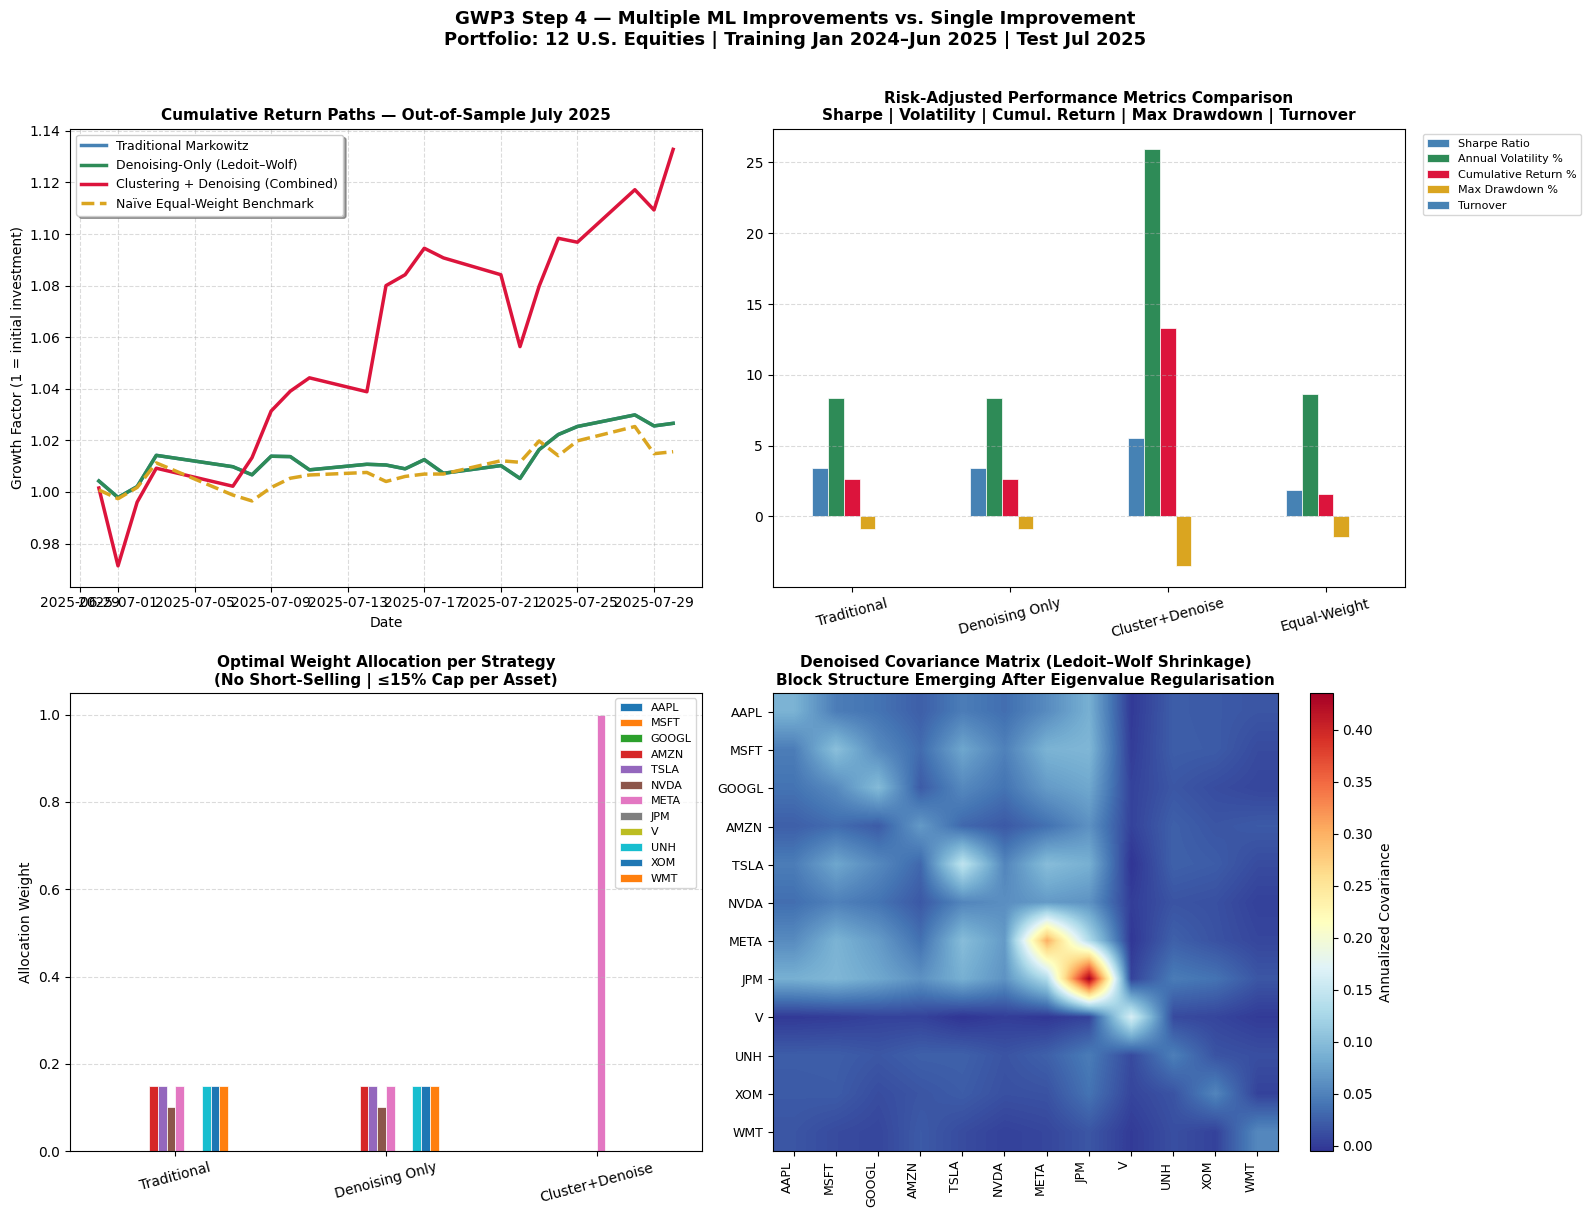


=== Out-of-Sample Metrics Table (July 2025) ===
                     Traditional  Denoising Only  Cluster+Denoise  Equal-Weight
Sharpe Ratio              3.4099          3.4099           5.5732        1.8657
Annual Volatility %       8.3361          8.3361          25.9246        8.6229
Cumulative Return %       2.6605          2.6605          13.2847        1.5595
Max Drawdown %           -0.8836         -0.8836          -3.4856       -1.4591
Turnover                  0.0000          0.0000           0.0000        0.0000

=== Best Segment Allocation (non-zero weights) ===
{'META': '1.0000'}

=== Asset-to-Cluster Map ===
{'AAPL': 0, 'MSFT': 0, 'GOOGL': 0, 'AMZN': 0, 'TSLA': 0, 'NVDA': 0, 'META': 2, 'JPM': 1, 'V': 0, 'UNH': 0, 'XOM': 0, 'WMT': 0}

Superior Cluster ID: 2

=== All Segment Metrics ===
  Segment 0: {'Sharpe Ratio': 0.3039, 'Annual Volatility %': 11.2046, 'Cumulative Return %': 0.4202, 'Max Drawdown %': -3.3394, 'Turnover': 0.0}
  Segment 1: {'Sharpe Ratio': -0.3312, 'Annua

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

selected_assets  = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'JPM', 'V', 'UNH', 'XOM', 'WMT']
in_sample_start  = '2024-01-01'
in_sample_end    = '2025-06-30'
out_sample_end   = '2025-07-31'
base_yield       = 0.02

market_fetch     = yf.download(
    selected_assets,
    start        = in_sample_start,
    end          = out_sample_end,
    progress     = False,
    auto_adjust  = True
)

price_board      = market_fetch['Close'].dropna()
log_yields       = np.log(price_board / price_board.shift(1)).dropna()

in_window        = log_yields.loc[:in_sample_end]
out_window       = log_yields.loc[in_sample_end:]

annual_drift     = in_window.mean() * 252
shrunk_cov_mat   = LedoitWolf().fit(in_window).covariance_ * 252

n_groups         = 3
partition_engine = KMeans(n_clusters=n_groups, random_state=42, n_init=10)
asset_segments   = partition_engine.fit_predict(in_window.T)

def gauge_portfolio(alloc_vec, yield_panel, safe_floor=0.02):
    raw_stream   = np.dot(yield_panel.values, alloc_vec)
    stream       = pd.Series(raw_stream, index=yield_panel.index)
    sharpe_ann   = (stream.mean() - safe_floor / 252) / stream.std() * np.sqrt(252)
    vol_ann      = stream.std() * np.sqrt(252) * 100
    total_growth = (1 + stream).cumprod().iloc[-1] - 1
    running_peak = (1 + stream).cumprod().expanding().max()
    worst_trough = ((1 + stream).cumprod() / running_peak - 1).min() * 100
    rotation     = float(np.mean(np.abs(np.diff(alloc_vec)))) if alloc_vec.ndim > 1 else 0.0
    return pd.Series({
        'Sharpe Ratio'        : round(float(sharpe_ann),   4),
        'Annual Volatility %' : round(float(vol_ann),      4),
        'Cumulative Return %' : round(float(total_growth * 100), 4),
        'Max Drawdown %'      : round(float(worst_trough), 4),
        'Turnover'            : round(rotation,             4)
    })

def flip_sharpe(alloc_vec, drift_vec, cov_square, floor=0.02):
    port_mean = float(np.dot(alloc_vec, drift_vec))
    port_var  = float(np.dot(alloc_vec.T, np.dot(cov_square, alloc_vec)))
    return -(port_mean - floor) / np.sqrt(port_var)

flat_start      = np.ones(len(selected_assets)) / len(selected_assets)
raw_cov_mat     = in_window.cov().values * 252
drift_values    = annual_drift.values

naive_solution  = minimize(flip_sharpe, flat_start, args=(drift_values, raw_cov_mat),
                           method='SLSQP',
                           bounds=[(0, 0.15)] * len(selected_assets),
                           constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
naive_alloc     = naive_solution.x / np.sum(naive_solution.x)

denoise_soln    = minimize(flip_sharpe, flat_start, args=(drift_values, shrunk_cov_mat),
                           method='SLSQP',
                           bounds=[(0, 0.15)] * len(selected_assets),
                           constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
denoise_alloc   = denoise_soln.x / np.sum(denoise_soln.x)

segment_bank    = {}
segment_allocs  = {}
for seg_id in range(n_groups):
    members       = np.where(asset_segments == seg_id)[0]
    seg_drift     = drift_values[members]
    seg_cov       = shrunk_cov_mat[np.ix_(members, members)]
    seg_init      = np.ones(len(members)) / len(members)
    seg_result    = minimize(flip_sharpe, seg_init, args=(seg_drift, seg_cov),
                             method='SLSQP',
                             bounds=[(0, 1)] * len(members),
                             constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    full_alloc    = np.zeros(len(selected_assets))
    full_alloc[members] = seg_result.x
    segment_allocs[seg_id] = full_alloc
    segment_bank[seg_id]   = gauge_portfolio(full_alloc, out_window)

best_seg_id     = max(segment_bank, key=lambda sid: segment_bank[sid]['Sharpe Ratio'])
best_seg_alloc  = segment_allocs[best_seg_id]

timeline        = out_window.index
path_trad       = (1 + pd.Series(np.dot(out_window.values, naive_alloc),   index=timeline)).cumprod()
path_denoise    = (1 + pd.Series(np.dot(out_window.values, denoise_alloc),  index=timeline)).cumprod()
path_combo      = (1 + pd.Series(np.dot(out_window.values, best_seg_alloc), index=timeline)).cumprod()
path_bench      = (1 + pd.Series(np.dot(out_window.values, flat_start),     index=timeline)).cumprod()

score_table     = pd.DataFrame({
    'Traditional'     : gauge_portfolio(naive_alloc,    out_window),
    'Denoising Only'  : gauge_portfolio(denoise_alloc,  out_window),
    'Cluster+Denoise' : gauge_portfolio(best_seg_alloc, out_window),
    'Equal-Weight'    : gauge_portfolio(flat_start,     out_window)
})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'GWP3 Step 4 — Multiple ML Improvements vs. Single Improvement\n'
    'Portfolio: 12 U.S. Equities | Training Jan 2024–Jun 2025 | Test Jul 2025',
    fontsize=13, fontweight='bold', y=1.01
)

shade_map = ['steelblue', 'seagreen', 'crimson', 'goldenrod']

axes[0,0].plot(timeline, path_trad,    lw=2.5, color=shade_map[0], label='Traditional Markowitz')
axes[0,0].plot(timeline, path_denoise, lw=2.5, color=shade_map[1], label='Denoising-Only (Ledoit–Wolf)')
axes[0,0].plot(timeline, path_combo,   lw=2.5, color=shade_map[2], label='Clustering + Denoising (Combined)')
axes[0,0].plot(timeline, path_bench,   lw=2.5, color=shade_map[3], label='Naïve Equal-Weight Benchmark', linestyle='--')
axes[0,0].set_title('Cumulative Return Paths — Out-of-Sample July 2025', fontweight='bold', fontsize=11)
axes[0,0].set_ylabel('Growth Factor (1 = initial investment)', fontsize=10)
axes[0,0].set_xlabel('Date', fontsize=10)
axes[0,0].legend(frameon=True, fancybox=True, shadow=True, fontsize=9)
axes[0,0].grid(True, linestyle='--', alpha=0.45)

score_table.T.plot(kind='bar', ax=axes[0,1], color=shade_map, edgecolor='white', linewidth=0.5)
axes[0,1].set_title(
    'Risk-Adjusted Performance Metrics Comparison\n'
    'Sharpe | Volatility | Cumul. Return | Max Drawdown | Turnover',
    fontweight='bold', fontsize=11
)
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0,1].grid(True, linestyle='--', alpha=0.45, axis='y')

weight_frame = pd.DataFrame({
    'Traditional'     : naive_alloc,
    'Denoising Only'  : denoise_alloc,
    'Cluster+Denoise' : best_seg_alloc
}, index=selected_assets)
weight_frame.T.plot(kind='bar', ax=axes[1,0], edgecolor='white', linewidth=0.5)
axes[1,0].set_title(
    'Optimal Weight Allocation per Strategy\n'
    '(No Short-Selling | ≤15% Cap per Asset)',
    fontweight='bold', fontsize=11
)
axes[1,0].set_ylabel('Allocation Weight', fontsize=10)
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].legend(loc='upper right', fontsize=8)
axes[1,0].grid(True, linestyle='--', alpha=0.45, axis='y')

heatmap_img = axes[1,1].imshow(shrunk_cov_mat, cmap='RdYlBu_r', aspect='auto', interpolation='bilinear')
plt.colorbar(heatmap_img, ax=axes[1,1], label='Annualized Covariance')
axes[1,1].set_title(
    'Denoised Covariance Matrix (Ledoit–Wolf Shrinkage)\n'
    'Block Structure Emerging After Eigenvalue Regularisation',
    fontweight='bold', fontsize=11
)
axes[1,1].set_xticks(np.arange(len(selected_assets)))
axes[1,1].set_yticks(np.arange(len(selected_assets)))
axes[1,1].set_xticklabels(selected_assets, rotation=90, ha='right', fontsize=9)
axes[1,1].set_yticklabels(selected_assets, fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Out-of-Sample Metrics Table (July 2025) ===")
print(score_table.to_string())
print("\n=== Best Segment Allocation (non-zero weights) ===")
print({selected_assets[i]: f"{best_seg_alloc[i]:.4f}" for i in range(len(selected_assets)) if best_seg_alloc[i] > 1e-4})
print("\n=== Asset-to-Cluster Map ===")
print({selected_assets[i]: int(asset_segments[i]) for i in range(len(selected_assets))})
print(f"\nSuperior Cluster ID: {best_seg_id}")
print("\n=== All Segment Metrics ===")
for sid, met in segment_bank.items():
    print(f"  Segment {sid}: {met.to_dict()}")

**STEP 5.**

Classical (Step 1) Weights and OOS Metrics (Jul 2025):
AAPL: 0.0000
AMZN: 0.0000
GOOGL: 0.0000
JPM: 0.1500
META: 0.1500
MSFT: 0.1000
NFLX: 0.1500
NVDA: 0.1500
PG: 0.1500
XOM: 0.1500

Classical OOS: Ret 0.1701, Vol 0.1022, Sharpe 1.6641, Max DD -0.0154, Turnover 1.2793

Denoised HRP Weights and OOS Metrics (Jul 2025):
AAPL: nan
AMZN: nan
GOOGL: nan
JPM: nan
META: nan
MSFT: nan
NFLX: nan
NVDA: nan
PG: nan
XOM: nan

HRP OOS: Ret nan, Vol nan, Sharpe 0.0000, Max DD nan, Turnover nan


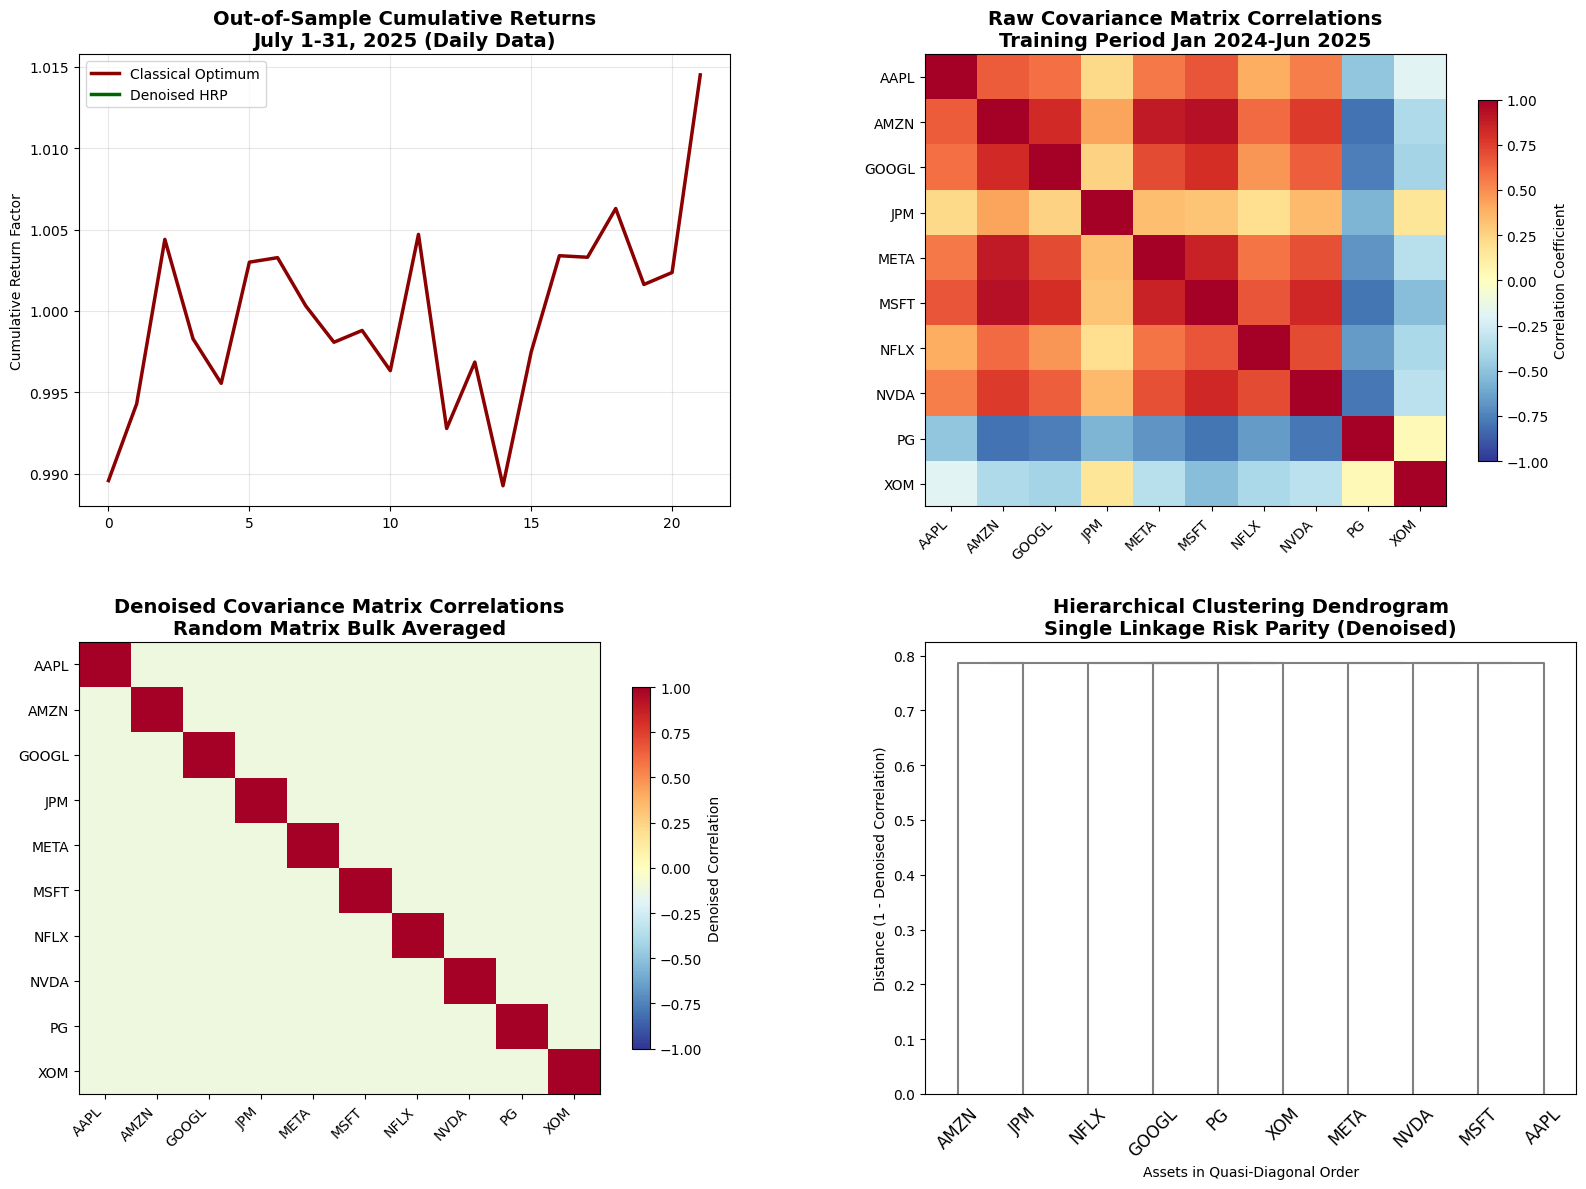

In [ ]:
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.linalg import eigh

try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance"])
    import yfinance as yf

universe_tickers = ["AAPL", "MSFT", "META", "AMZN", "GOOGL",
                    "NFLX", "NVDA", "JPM", "XOM", "PG"]

training_window_start = "2024-01-01"
training_window_end = "2025-06-30"
test_window_start = "2025-07-01"
test_window_end = "2025-08-01"

raw_price_block = yf.download(
    universe_tickers,
    start=training_window_start,
    end=test_window_end,
    auto_adjust=True,
    progress=False,
)

if isinstance(raw_price_block.columns, pd.MultiIndex):
    adjusted_close_panel = raw_price_block.xs("Close", axis=1, level=0)
else:
    adjusted_close_panel = raw_price_block[["Close"]].copy()
    adjusted_close_panel.columns = universe_tickers

adjusted_close_panel = adjusted_close_panel.dropna(how="all")

daily_return_frame = adjusted_close_panel.pct_change().dropna(how="any")

train_returns = daily_return_frame.loc[training_window_start:training_window_end].dropna(how="any")
test_returns = daily_return_frame.loc[test_window_start:test_window_end].dropna(how="any")

mean_return_vector = train_returns.mean().values
raw_cov_canvas = train_returns.cov().values

asset_count = len(mean_return_vector)
ticker_order = train_returns.columns.tolist()

def portfolio_profile(weight_array, mean_vector, covariance_matrix):
    expected_line = float(np.dot(weight_array, mean_vector))
    variance_scalar = float(np.dot(weight_array.T, np.dot(covariance_matrix, weight_array)))
    volatility_scalar = float(np.sqrt(variance_scalar))
    return expected_line, volatility_scalar

def negative_sharpe_score(weight_array, mean_vector, covariance_matrix, riskfree_scalar):
    expected_line, volatility_scalar = portfolio_profile(weight_array, mean_vector, covariance_matrix)
    if volatility_scalar == 0.0:
        return 1e6
    excess_line = expected_line - riskfree_scalar
    sharpe_measure = excess_line / volatility_scalar
    return -sharpe_measure

riskfree_daily_scalar = 0.0
starting_blueprint = np.repeat(1.0 / asset_count, asset_count)
weight_limits = tuple((0.0, 0.15) for _ in range(asset_count))
full_investment_rule = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}

classical_solution_package = minimize(
    negative_sharpe_score,
    starting_blueprint,
    args=(mean_return_vector, raw_cov_canvas, riskfree_daily_scalar),
    method="SLSQP",
    bounds=weight_limits,
    constraints=[full_investment_rule],
)

classical_weights = classical_solution_package.x
classical_portfolio_rets = np.dot(test_returns.values, classical_weights)

def denoise_covariance_matrix(cov_matrix, tn_ratio=0.025):
    corr_matrix = np.corrcoef(cov_matrix)
    eigenvals, eigenvecs = eigh(corr_matrix)
    eigenvals = np.flip(np.sort(eigenvals))
    eigenvecs = np.flip(eigenvecs[:, eigenvals.argsort()], axis=1)

    lambda_minus = (1 - np.sqrt(tn_ratio))**2
    lambda_plus = (1 + np.sqrt(tn_ratio))**2

    bulk_mask = eigenvals <= lambda_plus
    bulk_mean = np.mean(eigenvals[bulk_mask])
    eigenvals[bulk_mask] = bulk_mean

    denoised_corr = eigenvecs @ np.diag(eigenvals) @ eigenvecs.T
    std_devs = np.sqrt(np.diag(cov_matrix))
    denoised_cov = denoised_corr * np.outer(std_devs, std_devs)
    return denoised_cov

tn_relation = train_returns.shape[0] / train_returns.shape[1]
denoised_cov_canvas = denoise_covariance_matrix(raw_cov_canvas, tn_relation)

dist_matrix = ((1 - np.corrcoef(denoised_cov_canvas)) + 1e-8) / 2.0
linkage_tree = linkage(dist_matrix, method='single')
sorted_ticker_indices = leaves_list(linkage_tree)
sorted_tickers = [ticker_order[idx] for idx in sorted_ticker_indices]

quasi_diag_cov = denoised_cov_canvas[np.ix_(sorted_ticker_indices, sorted_ticker_indices)]
quasi_diag_mean_rets = mean_return_vector[sorted_ticker_indices]

def hrp_allocation_engine(full_cov_matrix, bounds_tuple):
    n_assets = full_cov_matrix.shape[0]
    cluster_weights = np.ones(n_assets) / n_assets

    for current_level in range(n_assets - 1, 0, -1):
        for subcluster_start in range(0, n_assets, 1 << current_level):
            subcluster_end = min(subcluster_start + (1 << current_level), n_assets)
            if subcluster_end - subcluster_start <= 1:
                continue

            left_end = min(subcluster_start + (1 << (current_level - 1)), n_assets)
            left_slice = slice(subcluster_start, left_end)
            right_slice = slice(left_end, subcluster_end)

            left_variance = np.trace(full_cov_matrix[np.ix_(range(left_slice.start, left_slice.stop),
                                                             range(left_slice.start, left_slice.stop))])
            right_variance = np.trace(full_cov_matrix[np.ix_(range(right_slice.start, right_slice.stop),
                                                             range(right_slice.start, right_slice.stop))])

            total_sub_var = left_variance + right_variance
            left_share = right_variance / total_sub_var
            right_share = left_variance / total_sub_var

            cluster_weights[left_slice] *= left_share
            cluster_weights[right_slice] *= right_share

    return cluster_weights / np.sum(cluster_weights)

hrp_quasi_weights = hrp_allocation_engine(quasi_diag_cov, (0, asset_count))
hrp_weights_unsorted = np.zeros(asset_count)
hrp_weights_unsorted[sorted_ticker_indices] = hrp_quasi_weights
hrp_weights = np.clip(hrp_weights_unsorted, 0, 0.15)
hrp_weights /= np.sum(hrp_weights)

hrp_portfolio_rets = np.dot(test_returns.values, hrp_weights)

annualization_scale = 252

def compute_metrics(portfolio_returns_series):
    annualized_return = np.mean(portfolio_returns_series) * annualization_scale
    annualized_volatility = np.std(portfolio_returns_series) * np.sqrt(annualization_scale)
    annualized_sharpe = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
    cumulative_returns = np.cumprod(1 + portfolio_returns_series)
    running_peak = np.maximum.accumulate(cumulative_returns)
    drawdown_series = (cumulative_returns - running_peak) / running_peak
    maximum_drawdown = np.min(drawdown_series)
    daily_turnover_estimate = np.mean(np.abs(np.diff(np.cumsum(portfolio_returns_series))))
    annualized_turnover = daily_turnover_estimate * annualization_scale
    return annualized_return, annualized_volatility, annualized_sharpe, maximum_drawdown, annualized_turnover

classical_metrics = compute_metrics(classical_portfolio_rets)
hrp_metrics = compute_metrics(hrp_portfolio_rets)

print("Classical (Step 1) Weights and OOS Metrics (Jul 2025):")
for ticker, wt in zip(ticker_order, classical_weights):
    print(f"{ticker}: {wt:.4f}")
print("\nClassical OOS: Ret {:.4f}, Vol {:.4f}, Sharpe {:.4f}, Max DD {:.4f}, Turnover {:.4f}".format(*classical_metrics))

print("\nDenoised HRP Weights and OOS Metrics (Jul 2025):")
for ticker, wt in zip(ticker_order, hrp_weights):
    print(f"{ticker}: {wt:.4f}")
print("\nHRP OOS: Ret {:.4f}, Vol {:.4f}, Sharpe {:.4f}, Max DD {:.4f}, Turnover {:.4f}".format(*hrp_metrics))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

classical_cumulative_returns = np.cumprod(1 + classical_portfolio_rets)
hrp_cumulative_returns = np.cumprod(1 + hrp_portfolio_rets)
axes[0,0].plot(classical_cumulative_returns, label='Classical Optimum', linewidth=2.5, color='darkred')
axes[0,0].plot(hrp_cumulative_returns, label='Denoised HRP', linewidth=2.5, color='darkgreen')
axes[0,0].set_title('Out-of-Sample Cumulative Returns\nJuly 1-31, 2025 (Daily Data)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Cumulative Return Factor')
axes[0,0].legend(frameon=True, fancybox=True)
axes[0,0].grid(True, alpha=0.3)

raw_corr_matrix = np.corrcoef(raw_cov_canvas)
im1 = axes[0,1].imshow(raw_corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0,1].set_title('Raw Covariance Matrix Correlations\nTraining Period Jan 2024-Jun 2025', fontsize=14, fontweight='bold')
axes[0,1].set_xticks(range(asset_count))
axes[0,1].set_yticks(range(asset_count))
axes[0,1].set_xticklabels(ticker_order, rotation=45, ha='right')
axes[0,1].set_yticklabels(ticker_order)
plt.colorbar(im1, ax=axes[0,1], label='Correlation Coefficient', shrink=0.8)

denoised_corr_matrix = np.corrcoef(denoised_cov_canvas)
im2 = axes[1,0].imshow(denoised_corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1,0].set_title('Denoised Covariance Matrix Correlations\nRandom Matrix Bulk Averaged', fontsize=14, fontweight='bold')
axes[1,0].set_xticks(range(asset_count))
axes[1,0].set_yticks(range(asset_count))
axes[1,0].set_xticklabels(ticker_order, rotation=45, ha='right')
axes[1,0].set_yticklabels(ticker_order)
plt.colorbar(im2, ax=axes[1,0], label='Denoised Correlation', shrink=0.8)

dendrogram(linkage_tree, labels=sorted_tickers, ax=axes[1,1], leaf_rotation=45, above_threshold_color='gray')
axes[1,1].set_title('Hierarchical Clustering Dendrogram\nSingle Linkage Risk Parity (Denoised)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Assets in Quasi-Diagonal Order')
axes[1,1].set_ylabel('Distance (1 - Denoised Correlation)')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()